# Environment

In [2]:
import os
import sys
from dotenv import load_dotenv

load_dotenv(override=True)
# set project folder
sys.path.append(os.environ.get('PROJECT_ROOT'))


In [3]:
%load_ext autoreload
%autoreload 2

# Models

In [27]:
import os
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings

llm = init_chat_model("gpt-4o-mini", model_provider="openai")
embeddings = OpenAIEmbeddings(model='text-embedding-3-small')

In [5]:
from ragas.llms import llm_factory, LangchainLLMWrapper, LlamaIndexLLMWrapper, HaystackLLMWrapper

ragas_llm = LangchainLLMWrapper(llm)
# ragas_llm = LlamaIndexLLMWrapper(llm)
# ragas_llm = HaystackLLMWrapper(llm)

ragas_llm = llm_factory()

D:\Programs\.pyenv\pyenv-win\versions\3.10.0\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
from langfuse.langchain import CallbackHandler
from langchain.schema.runnable import RunnableLambda
 
langfuse_handler = CallbackHandler()
langfuse_config = {"callbacks": [langfuse_handler]}
chain = RunnableLambda(lambda x: llm.invoke(x))
response = chain.invoke("hi", config=langfuse_config)
response

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_34a54ae93c', 'id': 'chatcmpl-BkneUQvMYjFgFP0esCIUarqhVQLsi', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--e61723d6-0398-462d-8f1e-3af2a5c8e8a0-0', usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [28]:
from ragas.embeddings import embedding_factory, LangchainEmbeddingsWrapper, LlamaIndexEmbeddingsWrapper, HaystackEmbeddingsWrapper

ragas_embeddings = LangchainEmbeddingsWrapper(embeddings)
# ragas_embeddings = LlamaIndexEmbeddingsWrapper(embeddings)
# ragas_embeddings = HaystackEmbeddingsWrapper(embeddings)

# ragas_embeddings = embedding_factory()

# Metrics

## 1. End-to-End Metrics
Focus on assessing the final output’s quality from end to end, based on the generated response.

### Align with Question

##### AnswerRelevancy

In [ ]:
from ragas.metrics import answer_relevancy, AnswerRelevancy
from ragas.dataset_schema import SingleTurnSample

sample = SingleTurnSample(
    user_input="is it a dog?",
    # user_input="Which city is the capital of France?",
    response="The capital of France is Paris.",
)

scorer = AnswerRelevancy(llm=ragas_llm, embeddings=ragas_embeddings)
scorer.single_turn_score(sample)

##### MultiModalRelevance

In [ ]:
from ragas.metrics import multimodal_relevance
from ragas.dataset_schema import SingleTurnSample

# if the question doesn't reference context, no context is needed
# if context is not empty, will be considered
# requires only one related context
# img context first
# if images contained, text contexts will be ignore
sample = SingleTurnSample(
    user_input="Describe a dog.",
    response="It is a Golden Retriever. It has a golden coat and looks very friendly.",
    retrieved_contexts=[
        # "cat is cute",
        # "Golden Retrievers are large-sized, friendly dogs known for their golden coats and intelligence.",
        # "resource/cat.jpg",
        # "resource/golden_retriever_dog.jpg",
    ]
)

multimodal_relevance.llm = ragas_llm
await multimodal_relevance.single_turn_ascore(sample)

##### AgentGoalAccuracyWithoutReference

In [ ]:
from ragas.metrics import AgentGoalAccuracyWithoutReference
from ragas.dataset_schema import MultiTurnSample

sample = MultiTurnSample(
    user_input=[
        {"content": "Which city is the capital of France?", "type": "human"}, 
        {"content": "The capital of France is Paris.", "type": "ai"}, 
        {"content": "What about Germany?", "type": "human"}, 
        {"content": "Berlin is the capital of Germany.", "type": "ai"}, 
        # {"content": "Sydney is the capital of Germany.", "type": "ai"}, 
    ],
)
scorer = AgentGoalAccuracyWithoutReference(llm=ragas_llm)
scorer.multi_turn_score(sample)

##### AgentGoalAccuracyWithReference

In [ ]:
from ragas.metrics import AgentGoalAccuracyWithReference
from ragas.dataset_schema import MultiTurnSample

sample = MultiTurnSample(
    user_input=[
        # {"content": "Which city is the capital of France?", "type": "human"}, 
        # {"content": "The capital of France is Paris.", "type": "ai"}, 
        {"content": "How did the Asian sales team perform last year?", "type": "human"},
        {"content": "The Asian sales team generated $4.1 million in revenue last year.", "type": "ai"},
        {"content": "What about the European sales team?", "type": "human"},
        {"content": "In 2023, the European sales team generated $3.2 million in revenue.", "type": "ai"},
    ],
    reference="In 2023, the European sales team generated $3.2M and the Asian sales team generated $4.1M in revenue."
)
scorer = AgentGoalAccuracyWithReference(llm=ragas_llm)
scorer.multi_turn_score(sample)

### Align with GroundTruth

##### AnswerAccuracy

In [ ]:
from ragas.metrics import AnswerAccuracy
from ragas.dataset_schema import SingleTurnSample

# consider user input
# consider scores from two different prompts
sample = SingleTurnSample(
    user_input="What is the boiling point of water at sea level?",
    response="Water boils at 100 degrees.",
    reference="The boiling point of water at sea level is 100 degrees Celsius.",
)

scorer = AnswerAccuracy(llm=ragas_llm)
await scorer.single_turn_ascore(sample)

##### FactualCorrectness

In [ ]:
from ragas.dataset_schema import SingleTurnSample
from ragas.metrics import FactualCorrectness

sample = SingleTurnSample(
    # response="The Eiffel Tower is built in Paris",
    response="The Eiffel Tower is built in Paris, which is the capital of France",
    reference="The Eiffel Tower is located in Paris."
    # reference="The Eiffel Tower is located in Paris, with a height of 1000ft."
)

scorer = FactualCorrectness(
    llm = ragas_llm,
    # mode='recall',
)
await scorer.single_turn_ascore(sample)

##### AnswerSimilarity

In [ ]:
from ragas.dataset_schema import SingleTurnSample
from ragas.metrics import answer_similarity

sample = SingleTurnSample(
    response="The Eiffel Tower is located in Paris.",
    reference="The Eiffel Tower is located in Paris. I has a height of 1000ft."
)

answer_similarity.llm = ragas_llm
answer_similarity.embeddings = ragas_embeddings
await answer_similarity.single_turn_ascore(sample)

##### AnswerCorrectness

In [ ]:
from ragas.metrics import answer_correctness
from ragas.dataset_schema import SingleTurnSample

# consider user input
sample = SingleTurnSample(
    user_input="What is the population of Japan?",
    response="Japan has about 125 million people.",
    reference="The population of Japan is approximately 126 million."
)
answer_correctness.llm = ragas_llm
answer_correctness.answer_similarity = answer_similarity
answer_correctness.weights = [0.75, 0.25]
await answer_correctness.single_turn_ascore(sample)

##### BleuScore

In [ ]:
from ragas.metrics import BleuScore
from ragas.dataset_schema import SingleTurnSample

# based on literal matching (n-gram overlap), used for Machine Translation
sample = SingleTurnSample(
    response="Japan has about 125 million people.",
    reference="The population of Japan is approximately 126 million."
)

scorer = BleuScore()
await scorer.single_turn_ascore(sample)

##### RougeScore

In [ ]:
from ragas.metrics import RougeScore
from ragas.dataset_schema import SingleTurnSample

# based on literal matching, used for Text Summarization
sample = SingleTurnSample(
    response="Japan has about 125 million people.",
    reference="The population of Japan is approximately 126 million."
)

scorer = RougeScore()
await scorer.single_turn_ascore(sample)

## 2. Retrieval Metrics
Measure the retrieval quality.

### Qualitative

##### ContextRelevance

In [ ]:
from ragas.metrics import ContextRelevance
from ragas.dataset_schema import SingleTurnSample

sample = SingleTurnSample(
    user_input="How did the Asian sales team perform in 2024?",
    retrieved_contexts=[
        # "The Asian sales team achieved $4.1 million in revenue in 2024.",
        "The European sales team generated $3.2 million in 2024.",
        "The marketing budget was increased by 10%."
    ]
)
sample = SingleTurnSample(
    user_input="What is the boiling point of water at sea level?",
    retrieved_contexts=[
        "The boiling point of water is affected by altitude. At sea level, it is typically 100 degrees Celsius.",
    ]
)

scorer = ContextRelevance(llm=ragas_llm)
await scorer.single_turn_ascore(sample)

##### MultiModalRelevance

In [ ]:
from ragas.metrics import multimodal_relevance
from ragas.dataset_schema import SingleTurnSample

# if the question doesn't reference context, no context is needed
# if context is not empty, will be considered
# requires only one related context
# img context first
# if images contained, text contexts will be ignore
sample = SingleTurnSample(
    user_input="Describe a dog.",
    response="It is a Golden Retriever. It has a golden coat and looks very friendly.",
    retrieved_contexts=[
        # "cat is cute",
        # "Golden Retrievers are large-sized, friendly dogs known for their golden coats and intelligence.",
        # "resource/cat.jpg",
        # "resource/golden_retriever_dog.jpg",
    ]
)

multimodal_relevance.llm = ragas_llm
await multimodal_relevance.single_turn_ascore(sample)

### Quantitative

#### Precision

##### ContextPrecision

In [ ]:
from ragas.metrics import context_precision
from ragas.dataset_schema import SingleTurnSample

# based on ground truth
sample = SingleTurnSample(
    # user_input="What's the difference between cat and dog?",
    user_input="Who is the head of the sales team?",
    reference="The head of the sales team is Li Hua.",
    retrieved_contexts=[
        "Li Hua is the head of the sales team.",    # position
        "Our company has six offices across the country.",
        "Zhang Wei is the head of the marketing department."
    ]
)

context_precision.llm = ragas_llm
await context_precision.single_turn_ascore(sample)

##### NonLLMContextPrecisionWithReference

In [ ]:
from ragas.metrics import NonLLMContextPrecisionWithReference
from ragas.dataset_schema import SingleTurnSample

# based on ground truth
sample = SingleTurnSample(
    # user_input="What's the difference between cat and dog?",
    user_input="Who is the head of the sales team?",
    reference_contexts=["Li Hua is the head of the sales team."],
    retrieved_contexts=[
        "Li Hua is the head of the sales team.",    # position
        "Zhang Wei is the head of the marketing department.",
        "Our company has six offices across the country.",
        "Our company has six offices across the country.",
    ]
)

# without llm
non_llm_precision = NonLLMContextPrecisionWithReference()
await non_llm_precision.single_turn_ascore(sample)

#### Recall

##### ContextRecall

In [ ]:
from ragas.dataset_schema import SingleTurnSample
from ragas.metrics import context_recall

sample = SingleTurnSample(
    user_input="Tell me knowledge about Eiffel Tower?",
    reference = "The Eiffel Tower is located in Paris. It was designed by Gustave Eiffel. It is the tallest building in that area.",
    retrieved_contexts=[
        # "The tower is in the capital of France.",
        "The tower is in the capital of France and designed by Gustave Eiffel.",
    ]
)
context_recall.llm = ragas_llm
await context_recall.single_turn_ascore(sample)

##### ContextEntityRecall

In [ ]:
from ragas.dataset_schema import SingleTurnSample
from ragas.metrics import context_entity_recall

# irrelevant to the user input
sample = SingleTurnSample(
    reference = "The Eiffel Tower is located in Paris and designed by Gustave Eiffel.",
    retrieved_contexts=[
        "The tower is in the capital of France.",
        "The Eiffel Tower was designed by Gustave Eiffel.",
    ]
)
context_entity_recall.llm = ragas_llm
await context_entity_recall.single_turn_ascore(sample)

##### NonLLMContextRecall

In [ ]:
from ragas.dataset_schema import SingleTurnSample
from ragas.metrics import NonLLMContextRecall

sample = SingleTurnSample(
    reference_contexts=["Paris is the capital of France.", "The Eiffel Tower is one of the most famous landmarks in Paris."],
    retrieved_contexts=["Paris is the capital of France."], 
)

context_recall = NonLLMContextRecall()
await context_recall.single_turn_ascore(sample)

## 3. Generation Metrics (based on Retrieval)
Measure the faithfulness of the answer to the retrieved context to detect LLM hallucination.

### Qualitative

##### ResponseGroundedness

In [ ]:
from ragas.metrics import ResponseGroundedness
from ragas.dataset_schema import SingleTurnSample

sample = SingleTurnSample(
    response="In 2024, the Asian sales team generated $4.1 million.",
    retrieved_contexts=[
        "The Asian sales team achieved $4.1 million in revenue in 2024.",
        "The European sales team generated $3.2 million in 2024.",
        "The marketing budget was increased by 10%."
    ]
)

scorer = ResponseGroundedness(llm=ragas_llm)
await scorer.single_turn_ascore(sample)

##### MultiModalFaithfulness

In [ ]:
from ragas.metrics import multimodal_faithness
from ragas.dataset_schema import SingleTurnSample

# requires only one related context
# img context first
# if images contained, text contexts will be ignore
sample = SingleTurnSample(
    response="It is a Golden Retriever. It has a golden coat and looks very friendly.",
    retrieved_contexts=[
        "cat is cute",
        "Golden Retrievers are large-sized, friendly dogs known for their golden coats and intelligence.",
        "resource/cat.jpg",
        "resource/golden_retriever_dog.jpg",
    ]
)

multimodal_faithness.llm = ragas_llm
await multimodal_faithness.single_turn_ascore(sample)

### Quantitative

##### Faithfulness

In [ ]:
from ragas.dataset_schema import SingleTurnSample
from ragas.metrics import faithfulness
sample = SingleTurnSample(
    user_input="Who is the leader of the sales team?",
    # response="The leader of the sales team is Li Hua.",
    response="The head of the sales team is Li Hua and Wang.",
    retrieved_contexts=[
        "Li Hua is the leader of the sales team.",
        "Our company has six offices across the country.",
        "Zhang Wei is the leader of the marketing department."
    ]
)

faithfulness.llm = ragas_llm
await faithfulness.single_turn_ascore(sample)

##### FaithfulnesswithHHEM
Hallucination Human Evaluation Metric

In [ ]:
from transformers import AutoModelForSequenceClassification

# trust_remote_code=True: allow executing remote code locally
hhem_model = AutoModelForSequenceClassification.from_pretrained(
    'vectara/hallucination_evaluation_model', trust_remote_code=True)

# pairs of content and response
pairs = [
    ("The capital of France is Berlin.", "The capital of France is Paris."),
    ('I am in California', 'I am in United States.'), 
    ('I am in United States', 'I am in California.'),
    ("Mark Wahlberg was a fan of Manny.", "Manny was a fan of Mark Wahlberg."), 
    ("A person on a horse jumps over a broken down airplane.", "A person is outdoors, on a horse."),
    ("A boy is jumping on skateboard in the middle of a red bridge.", "The boy skates down the sidewalk on a red bridge"),
    ("A man with blond-hair, and a brown shirt drinking out of a public water fountain.", "A blond man wearing a brown shirt is reading a book."),
]

hhem_model.predict(pairs)

In [ ]:
from ragas.dataset_schema import SingleTurnSample
from ragas.metrics import FaithfulnesswithHHEM

sample = SingleTurnSample(
    user_input="What is the capital of France?",
    response="The capital of France is Paris.",
    retrieved_contexts=[
        "France's capital city is Berlin, which is known for the Eiffel Tower and its rich cultural history."
    ]
)

scorer = FaithfulnesswithHHEM(llm=ragas_llm)
await scorer.single_turn_ascore(sample)


##### ContextUtilization

In [ ]:
from ragas.metrics import ContextUtilization
from ragas.dataset_schema import SingleTurnSample

# based on response
sample = SingleTurnSample(
    # user_input="What's the difference between cat and dog?",
    user_input="Who is the head of the sales team?",
    response="The head of the sales team is Li Hua. Yang is the leader of financial team",
    retrieved_contexts=[
        "Our company has six offices across the country.",
        "Li Hua is the head of the sales team.",    # position
        "Zhang Wei is the head of the marketing department."
    ]
)

scorer = ContextUtilization(llm=ragas_llm)
await scorer.single_turn_ascore(sample)

## 4. Specific-Task Metrics

##### SummarizationScore

In [ ]:
from ragas.dataset_schema import SingleTurnSample
from ragas.metrics import SummarizationScore


sample = SingleTurnSample(
    response="A company is launching a fitness tracking app that helps users set exercise goals, log meals, and track water intake, with personalized workout suggestions and motivational reminders.",
    reference_contexts=[
        "A company is launching a new product, a smartphone app designed to help users track their fitness goals. The app allows users to set daily exercise targets, log their meals, and track their water intake. It also provides personalized workout recommendations and sends motivational reminders throughout the day."
    ]
)

scorer = SummarizationScore(
    llm=ragas_llm,
    coeff=0.5
)
await scorer.single_turn_ascore(sample)

##### TopicAdherenceScore

In [ ]:
from ragas.dataset_schema import MultiTurnSample
from ragas.metrics import TopicAdherenceScore

sample = MultiTurnSample(
    user_input=[
        {"content": "What are the city’s plans for public transport?", "type": "human"},
        {"content": "The city will add more electric buses and expand bike lanes.", "type": "ai"},
        {"content": "Will they improve green spaces too?", "type": "human"},
        {"content": "Yes, they plan to plant more trees and build new parks.", "type": "ai"},
    ],
    reference_topics=[
        "electric buses",
        "bike lanes",
        "trees",
        "public parks",
    ],
)

scorer = TopicAdherenceScore(
    llm=ragas_llm,
    mode="f1"
)

score = await scorer.multi_turn_ascore(sample)
print(score)

##### ToolCallAccuracy

In [ ]:
from ragas.metrics import ToolCallAccuracy
from ragas.dataset_schema import  MultiTurnSample
from ragas.messages import HumanMessage,AIMessage,ToolMessage,ToolCall

user_input = [
    HumanMessage(content="What's the weather like in New York right now?"),
    AIMessage(content="The current temperature in New York is 75°F and it's partly cloudy.", tool_calls=[
        ToolCall(name="weather_check", args={"location": "New York"})
    ]),
    HumanMessage(content="Can you translate that to Celsius?"),
    AIMessage(content="Let me convert that to Celsius for you.", tool_calls=[
        ToolCall(name="temperature_conversion", args={"temperature_fahrenheit": 75})
    ]),
    ToolMessage(content="75°F is approximately 23.9°C."),
    AIMessage(content="75°F is approximately 23.9°C.")
]

sample = MultiTurnSample(
    user_input=user_input,
    reference_tool_calls=[
        ToolCall(name="weather_check", args={"location": "New York"}),
        ToolCall(name="temperature_conversion", args={"temperature_fahrenheit": 75})
    ]
)

scorer = ToolCallAccuracy()
await scorer.multi_turn_ascore(sample)

##### LLMSQLEquivalence

In [ ]:
from ragas.metrics import LLMSQLEquivalence
from ragas.dataset_schema import SingleTurnSample

# support one/multiple ground truth content, reference first
sample = SingleTurnSample(
    response="SELECT name FROM users WHERE age > 30;", 
    reference="SELECT users.name FROM users WHERE users.age > 30;", 
    reference_contexts= [], 
)

scorer = LLMSQLEquivalence(llm = ragas_llm)
await scorer.single_turn_ascore(sample)

##### NoiseSensitivity

In [ ]:
from ragas.dataset_schema import SingleTurnSample
from ragas.metrics import NoiseSensitivity

sample = SingleTurnSample(
    user_input="What is the Life Insurance Corporation of India (LIC) known for?",
    response="The Life Insurance Corporation of India (LIC) is the largest insurance company in India, known for its vast portfolio of investments. LIC contributes to the financial stability of the country.",
    reference="The Life Insurance Corporation of India (LIC) is the largest insurance company in India, established in 1956 through the nationalization of the insurance industry. It is known for managing a large portfolio of investments.",
    retrieved_contexts=[
        "The Life Insurance Corporation of India (LIC) was established in 1956 following the nationalization of the insurance industry in India.",
        "LIC is the largest insurance company in India, with a vast network of policyholders and huge investments.",
        "As the largest institutional investor in India, LIC manages substantial funds, contributing to the financial stability of the country.",
        "The Indian economy is one of the fastest-growing major economies in the world, thanks to sectors like finance, technology, manufacturing etc."
    ]
)

scorer = NoiseSensitivity(
    llm=ragas_llm,
    mode='irrelevant',
)
await scorer.single_turn_ascore(sample)

## 5. Customized Metrics

### AspectCritic (Output: binary)

##### Custumized metric
- no specific input fields are required
- evaluate all provided content

In [ ]:
from ragas import SingleTurnSample
from ragas.metrics._aspect_critic import AspectCritic

# check if the dialogue related to new energe 
scorer = AspectCritic(
    name="mentions_new_energy",
    definition="Answer 'yes' only if the response mentions new energy topics such as solar power, wind energy, electric vehicles, or renewable energy.",
    llm=ragas_llm,
)


sample = SingleTurnSample(
    user_input="The company plans to invest in solar power and electric vehicles over the next five years."
)
score = await scorer.single_turn_ascore(sample)
print(score)

In [ ]:
print('-'*40)
print('name:', scorer.name)
print('required_columns:', scorer._required_columns)
print('output_type:', scorer.output_type)
print('llm:', scorer.llm)
print('-'*40)
# print('_definition:',scorer._definition)
# print('max_retries:', scorer.max_retries)
# print('Prompt:', scorer.single_turn_prompt)

##### Built-in metrics

In [ ]:
from ragas import SingleTurnSample
from ragas.metrics._aspect_critic import maliciousness, harmfulness

sample = SingleTurnSample(
    # user_input="Autistic people cannot feel emotions like normal people, so there's no point in including them in group activities.",
    user_input="He want to kill the cat.",
)

harmfulness.llm = ragas_llm
maliciousness.llm = ragas_llm
print('harmfulness', harmfulness.single_turn_score(sample))
print('conciseness', maliciousness.single_turn_score(sample))

In [ ]:
from ragas import SingleTurnSample
from ragas.metrics._aspect_critic import coherence, conciseness

sample = SingleTurnSample(
    # user_input="Plants make food. Blue sky."
    user_input="It is raining heavily outside, so you should take an umbrella because the weather is bad and wet.",
)

conciseness.llm = ragas_llm
coherence.llm = ragas_llm
print('conciseness', conciseness.single_turn_score(sample))
print('coherence', coherence.single_turn_score(sample))

In [ ]:
from ragas import SingleTurnSample
from ragas.metrics._aspect_critic import correctness

sample = SingleTurnSample(
    # user_input="The sky is blue."
    user_input="The sky is black."
)

correctness.llm = ragas_llm
print('correctness', correctness.single_turn_score(sample))

### SimpleCriteriaScore (Output: integer)

In [ ]:
from ragas.dataset_schema import SingleTurnSample
from ragas.metrics import SimpleCriteriaScore

# customer service quality check
scorer = SimpleCriteriaScore(
    name="issue_resolution_score",
    definition=(
        "Score how well the predicted response answers the user's question. "
        "Score  from 1 (bad) to 5 (excellent). "
    ),
    llm=ragas_llm
)


sample = SingleTurnSample(
    user_input="How can I change my subscription plan?",
    response="You can change your subscription plan in your account settings under the 'Subscription' tab.",
)
await scorer.single_turn_ascore(sample)

### RubricsScore (Output: integer)

In [ ]:
from ragas.dataset_schema import SingleTurnSample
from ragas.metrics import RubricsScore

# format: score(?)_description
rubrics = {
    "score1_description": "The response is irrelevant or misleading, and does not help the user resolve the issue.",
    "score2_description": "The response is partially helpful but lacks key instructions or contains confusing guidance.",
    "score3_description": "The response addresses the question, but misses important details or clarity.",
    "score4_description": "The response is mostly correct and helpful, with only minor omissions.",
    "score5_description": "The response is fully accurate, clear, and resolves the user's issue effectively."
}

sample = SingleTurnSample(
    user_input="How do I reset my account password?",
    response="Please visit our website and check the FAQ section.",
    ground_truth="To reset your password, go to the login page and click 'Forgot Password'. Follow the instructions sent to your email."
)
scorer = RubricsScore(rubrics=rubrics, llm=ragas_llm)
await scorer.single_turn_ascore(sample)

### InstanceRubrics (Output: integer)

In [ ]:
from ragas.dataset_schema import SingleTurnSample
from ragas import EvaluationDataset, evaluate
from ragas.metrics import InstanceRubrics

samples = [
    SingleTurnSample(
        user_input="Which city is the capital of France?",
        response="The capital of France is Sydney.",
        rubrics={
            "score1_description": "The response is completely incorrect.",
            "score5_description": "The response is completely accurate and detailed.",
        },
    ),
    SingleTurnSample(
        user_input="What is the population of Japan?",
        response="The population of Japan is approximately 126 million.",
        rubrics={
            "score1_description": "The response is completely incorrect.",
            "score5_description": "The response is completely accurate and detailed.",
        },
    ),
]

eval_dataset = EvaluationDataset(samples)

metrics = [InstanceRubrics()]

result = evaluate(
    dataset=eval_dataset,
    metrics=metrics,
    llm=ragas_llm,
)

print(result)


## 6. BatchMetricEvaluation

In [ ]:
from langchain.schema.runnable import RunnableLambda
from langchain.schema.runnable import RunnableParallel
import pandas as pd


samples = [
    SingleTurnSample(user_input="He want to kill the cat."),
    SingleTurnSample(user_input="Plants make food. Blue sky."),
    SingleTurnSample(user_input="The sky is black."),
]

metrics = [harmfulness, coherence, correctness]
# chain
metric_runnables = {
    m.name: RunnableLambda(lambda sample: m.single_turn_score(sample))
    for m in metrics
}
parallel_chain = RunnableParallel(metric_runnables)
result = parallel_chain.batch(samples)
# to pd
df = pd.DataFrame(result)
df

# Data Structures

## Sample

### SingleTurnSample

In [ ]:
# user_input: question
# response: answer
# retrieved_contexts: contexts
# reference: ground_truth

In [ ]:
from ragas import SingleTurnSample
from ragas.metrics import answer_relevancy

sample = SingleTurnSample(
    user_input="Which city is the capital of France?",
    response="The capital of France is Paris.",
)
answer_relevancy.llm = ragas_llm
answer_relevancy.embeddings = ragas_embeddings
answer_relevancy.single_turn_score(sample)

### MultiTurnSample

In [ ]:
from ragas.metrics import AgentGoalAccuracyWithoutReference
from ragas.dataset_schema import MultiTurnSample
from ragas.messages import AIMessage, HumanMessage

sample = MultiTurnSample(
    user_input=[
        {"content": "Which city is the capital of France?", "type": "human"}, 
        {"content": "The capital of France is Paris.", "type": "ai"}, 
        HumanMessage(content="What about Germany?"),
        AIMessage(content="Berlin is the capital of Germany."),
    ],
)
scorer = AgentGoalAccuracyWithoutReference(llm=ragas_llm)
scorer.multi_turn_score(sample)

## SampleSet and evaluate
Encapsulating multiple test cases for batch evaluate

### EvaluationDataset

In [7]:
from ragas.dataset_schema import SingleTurnSample
from ragas import EvaluationDataset

# create from samples
samples = [
    SingleTurnSample(user_input="Which city is the capital of France?", response="The capital of France is Sydney."),
    SingleTurnSample(user_input="What is the population of Japan?", response="The population of Japan is approximately 126 million."),
]

eval_dataset = EvaluationDataset(samples)
print(type(eval_dataset))

<class 'ragas.dataset_schema.EvaluationDataset'>


In [8]:
from ragas import EvaluationDataset

# create from json list
dataset = [
    {"user_input": "Which city is the capital of France?", "response" : "The capital of France is Sydney."},
    {"user_input": "What is the population of Japan?", "response" : "The population of Japan is approximately 126 million."}
]

eval_dataset = EvaluationDataset.from_list(dataset)
# eval_dataset = EvaluationDataset.from_dict(dataset)
print(type(eval_dataset))

<class 'ragas.dataset_schema.EvaluationDataset'>


In [10]:
print(eval_dataset[1])

user_input='What is the population of Japan?' retrieved_contexts=None reference_contexts=None response='The population of Japan is approximately 126 million.' multi_responses=None reference=None rubrics=None


##### evaluate


In [11]:
from ragas import evaluate
from ragas.metrics._aspect_critic import harmfulness, coherence, correctness

# default
# metrics = [answer_relevancy, context_precision, faithfulness, context_recall]
metrics = [harmfulness, coherence, correctness]

result = evaluate(
    dataset=eval_dataset,
    metrics=metrics,
    llm=ragas_llm,
    show_progress=True,
    # batch_size=2
)
result

Evaluating: 100%|████████████████████████████████████████████████████████████████████████| 6/6 [00:01<00:00,  3.22it/s]


{'harmfulness': 0.0000, 'coherence': 0.5000, 'correctness': 0.5000}

##### batch execute with chain


In [12]:
from langchain_core.runnables import RunnableLambda
from ragas.metrics._aspect_critic import correctness

correctness.llm = ragas_llm
result = RunnableLambda(lambda x: correctness.single_turn_score(x)).batch(eval_dataset)
result

[0, 1]

In [17]:
from langchain_core.runnables import RunnableParallel
from ragas.metrics._aspect_critic import harmfulness, coherence
# metrics
metrics=[harmfulness, coherence]
for n in metrics:
    n.llm = ragas_llm
    
# chain
parallel = RunnableParallel({
    m.name: lambda x, m=m: m.single_turn_score(x) for m in metrics
})
result = parallel.batch(eval_dataset)
result

[{'harmfulness': 0, 'coherence': 0}, {'harmfulness': 0, 'coherence': 1}]

###  HuggingFace Dataset

#### Online

In [ ]:
from datasets import load_dataset
# https://huggingface.co/datasets/explodinggradients/ragas-wikiqa


# wiki knowledge
eval_data = load_dataset("explodinggradients/ragas-wikiqa", split="train[:100]")
print(type(eval_data))
print(eval_data)

In [ ]:
from datasets import load_dataset

# Financial Q&A
eval_data = load_dataset("explodinggradients/fiqa", "ragas_eval", split="baseline")
print(eval_data)

In [ ]:
from datasets import load_dataset

# multi-hop question dataset
eval_data = load_dataset("rungalileo/ragbench", "hotpotqa", split="train[:100]")
print(eval_data)

In [ ]:
eval_data.to_pandas()['documents'][0]

In [22]:

# filter rows
selected_indices = [9, 15, 51, 97]
correct_before_ind = 2
dataset = eval_data.select(selected_indices)

# filter columns
dataset = dataset.map(lambda n, i: {
        "response": n["correct_answer"] if i < correct_before_ind else n["incorrect_answer"],
    },with_indices=True
)
dataset = dataset.select_columns([
    'question',
    'response',
    'correct_answer'
])
dataset = dataset.rename_columns({
    'question': 'user_input',
    'correct_answer': 'reference',
})
print(dataset)

Dataset({
    features: ['user_input', 'response', 'reference'],
    num_rows: 4
})


In [23]:
from utils.display_util import display_left_aligned



display_left_aligned(dataset.to_pandas())

,user_input,response,reference
0,what percentage of water in in the body,"Arthur Guyton 's Textbook of Medical Physiology states that ""the total amount of water in a man of average weight (70 kilograms) is approximately 40 litres, averaging 57 percent of his total body weight.","Arthur Guyton 's Textbook of Medical Physiology states that ""the total amount of water in a man of average weight (70 kilograms) is approximately 40 litres, averaging 57 percent of his total body weight."
1,where do crocodiles live,"Crocodiles (subfamily Crocodylinae) or true crocodiles are large aquatic tetrapods that live throughout the tropics in Africa , Asia , the Americas and Australia .","Crocodiles (subfamily Crocodylinae) or true crocodiles are large aquatic tetrapods that live throughout the tropics in Africa , Asia , the Americas and Australia ."
2,who owns youtube,"Most of the content on YouTube has been uploaded by individuals, although media corporations including CBS , the BBC , Vevo , Hulu , and other organizations offer some of their material via the site, as part of the YouTube partnership program.","In November 2006, YouTube, LLC was bought by Google for US$1.65 billion, and operates as a subsidiary of Google."
3,what year was the eiffel tower made,"During its construction, the Eiffel Tower surpassed the Washington Monument to assume the title of the tallest man-made structure in the world, a title it held for 41 years, until the Chrysler Building in New York City was built in 1930.","Erected in 1889 as the entrance arch to the 1889 World's Fair , it has become both a global cultural icon of France and one of the most recognizable structures in the world."


In [25]:
dataset = dataset.map(
    lambda example, idx: {
        "response": example["response"] + "He wants to kill the cat." if idx == 1 else example["response"]
    },
    with_indices=True
)

Map: 100%|███████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 169.60 examples/s]


In [29]:
from ragas import evaluate
from ragas.metrics import answer_relevancy
from ragas.metrics._aspect_critic import harmfulness
from ragas.metrics import FactualCorrectness

# metrics
factual_correctness = FactualCorrectness()
metrics=[answer_relevancy, factual_correctness, harmfulness]

result = evaluate(
    dataset=dataset, 
    metrics=metrics,
    llm=ragas_llm,
    embeddings=ragas_embeddings,
)
print(type(result))
print(result)
from ragas.dataset_schema import EvaluationResult

Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 12/12 [00:12<00:00,  1.02s/it]


<class 'ragas.dataset_schema.EvaluationResult'>
{'answer_relevancy': 0.6503, 'factual_correctness(mode=f1)': 0.4500, 'harmfulness': 0.2500}


In [30]:
print(result._repr_dict['answer_relevancy'])
print(result._repr_dict['factual_correctness(mode=f1)'])
print(result._repr_dict['harmfulness'])

0.6502890655840711
0.45
0.25


In [31]:
print(result['answer_relevancy'])
print(result['harmfulness'])
print(result['factual_correctness(mode=f1)'])

[np.float64(0.5066452701726601), np.float64(0.8381981815576006), np.float64(0.584743354772586), np.float64(0.6715694558334375)]
[0, 1, 0, 0]
[np.float64(1.0), np.float64(0.8), np.float64(0.0), np.float64(0.0)]


In [32]:
result.to_pandas()

,user_input,response,reference,answer_relevancy,factual_correctness(mode=f1),harmfulness
0,what percentage of water in in the body,Arthur Guyton 's Textbook of Medical Physiolog...,Arthur Guyton 's Textbook of Medical Physiolog...,0.506645,1.0,0
1,where do crocodiles live,Crocodiles (subfamily Crocodylinae) or true cr...,Crocodiles (subfamily Crocodylinae) or true cr...,0.838198,0.8,1
2,who owns youtube,Most of the content on YouTube has been upload...,"In November 2006, YouTube, LLC was bought by G...",0.584743,0.0,0
3,what year was the eiffel tower made,"During its construction, the Eiffel Tower surp...",Erected in 1889 as the entrance arch to the 18...,0.671569,0.0,0


#### Local

In [ ]:
from datasets import Dataset

data = {
    'user_input': [
        'what percentage of water in in the body',
        'where do crocodiles live',
        'who owns youtube',
        'what year was the eiffel tower made'
    ],
    'response': [
        'Arthur Guyton \'s Textbook of Medical Physiology states that "the total amount of water in a man of average weight (70 kilograms) is approximately 40 litres, averaging 57 percent of his total body weight.',
        'Crocodiles (subfamily Crocodylinae) or true crocodiles are large aquatic tetrapods that live throughout the tropics in Africa , Asia , the Americas and Australia .',
        'Most of the content on YouTube has been uploaded by individuals, although media corporations including CBS , the BBC , Vevo , Hulu , and other organizations offer some of their material via the site, as part of the YouTube partnership program.',
        'During its construction, the Eiffel Tower surpassed the Washington Monument to assume the title of the tallest man-made structure in the world, a title it held for 41 years, until the Chrysler Building in New York City was built in 1930.'],
    'reference': [
        'Arthur Guyton \'s Textbook of Medical Physiology states that "the total amount of water in a man of average weight (70 kilograms) is approximately 40 litres, averaging 57 percent of his total body weight.',
        'Crocodiles (subfamily Crocodylinae) or true crocodiles are large aquatic tetrapods that live throughout the tropics in Africa , Asia , the Americas and Australia .',
        'In November 2006, YouTube, LLC was bought by Google for US$1.65 billion, and operates as a subsidiary of Google.',
        "Erected in 1889 as the entrance arch to the 1889 World's Fair , it has become both a global cultural icon of France and one of the most recognizable structures in the world."
        ]
    }
eval_data = Dataset.from_dict(data)
print(type(eval_data))

In [ ]:
Dataset.from_csv()

# Testset Generation
RAGAS supports automatic testset generation from document corpus.

#### Document

##### load from Directory

In [37]:
from langchain_community.document_loaders import DirectoryLoader

loader = DirectoryLoader("./resource/markdown", glob="**/*.md")
docs_dir = loader.load()
print(len(docs_dir))
docs_dir

11


[Document(metadata={'source': 'resource\\markdown\\advisory-group-members.md'}, page_content='layout: default title: Advisory Group Members description: "This page lists the members of the Diversity, Inclusion & Belonging Advisory Group."\n\n{{< group-by-expertise "Diversity, Inclusion & Belonging Advisory Group" >}}'),
 Document(metadata={'source': 'resource\\markdown\\being-an-ally.md'}, page_content='title: "The Ally Lab" description: Learn what is an ally, how to be an ally and what it means to be an ally.\n\nWhat is an ally?\n\nA diversity, inclusion and belonging "ally" is someone who is willing to take action in support of another person, in order to remove barriers that impede that person from contributing their skills and talents in the workplace or community.\n\nBeing an ally is a verb, this means that you proactively and purposefully take action and is not something forced upon you.\n\nHow to be an ally\n\nIt is not required to be an ally to work at GitLab. At GitLab it is r

#### TestsetGenerator

In [33]:
from ragas.testset import TestsetGenerator
from utils.model_util import get_langchain_embeddings, get_langchain_llm

langchain_llm = get_langchain_llm()
langchain_embedding_model = get_langchain_embeddings()

testset_generator = TestsetGenerator.from_langchain(
    llm=langchain_llm,
    embedding_model=langchain_embedding_model,
)

#### Query distribution

In [40]:
from ragas.testset.synthesizers import default_query_distribution, SingleHopSpecificQuerySynthesizer, MultiHopAbstractQuerySynthesizer, MultiHopSpecificQuerySynthesizer


# query_distribution = default_query_distribution(ragas_llm)
query_distribution = [
    (SingleHopSpecificQuerySynthesizer(), 0.8),
    (MultiHopSpecificQuerySynthesizer(), 0.1),
    (MultiHopAbstractQuerySynthesizer(), 0.1),
]

In [18]:
context = {
    "fact1":"Alice was born in Boston in 1990.",
    "fact2":"She graduated from MIT in 2015.",
    "fact3":"In 2018 Alice moved to Seattle.",
    "fact4":"She joined CloudTech in 2018.",
}

single_specific_hop_question = "Where was Alice born?"
multi_specific_hop_question = "Where did Alice graduate from and where did she move in 2018?"
multi_abstract_hop_question = "Why did Alice move to Seattle?"

#### RunConfig

In [34]:
from ragas import RunConfig

config = RunConfig(
    timeout=180,        # max seconds in total
    max_retries=1,
    max_wait=60,        # emax seconds for each try
    max_workers=16,
    exception_types=(
        Exception, 
        # TimeoutError, 
        # ConnectionError,
    ),
    log_tenacity=False, # logging for retry
)

#### Generate Testset

In [41]:
testset = testset_generator.generate_with_langchain_docs(
    documents=docs_dir, 
    testset_size=10, 
    callbacks=None,
    with_debugging_logs=True,
    raise_exceptions=True,
    run_config=config,
    query_distribution = query_distribution,
)
testset

Applying HeadlineSplitter:   0%|                                                                | 0/11 [00:00<?, ?it/s]unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
Generating Samples: 100%|██████████████████████████████████████████████████████████████| 10/10 [00:03<00:00,  3.13it/s]


Testset(samples=[TestsetSample(eval_sample=SingleTurnSample(user_input='What resources does The Ally Lab provide for individuals looking to become better allies in promoting diversity and inclusion?', retrieved_contexts=None, reference_contexts=['title: "The Ally Lab" description: Learn what is an ally, how to be an ally and what it means to be an ally. What is an ally? A diversity, inclusion and belonging "ally" is someone who is willing to take action in support of another person, in order to remove barriers that impede that person from contributing their skills and talents in the workplace or community. Being an ally is a verb, this means that you proactively and purposefully take action and is not something forced upon you. How to be an ally It is not required to be an ally to work at GitLab. At GitLab it is required to be inclusive. Being an ally goes a step beyond being inclusive to taking action to support marginalized groups. The first step in being an ally is self-educating. T

In [42]:
df = testset.to_pandas()
print(len(df))
df

10


,user_input,reference_contexts,reference,synthesizer_name
0,What resources does The Ally Lab provide for i...,"[title: ""The Ally Lab"" description: Learn what...","The Ally Lab provides tools, resources, and le...",single_hop_specifc_query_synthesizer
1,How can Zoom be utilized to enhance allyship i...,[Skills and Behaviors of allies To be an effec...,Zoom can be utilized to enhance allyship by pr...,single_hop_specifc_query_synthesizer
2,What is allyship?,[Tips on being an ally Identifying your power ...,Allyship involves identifying your power and p...,single_hop_specifc_query_synthesizer
3,How does belonging relate to being an ally in ...,[What it means to be an ally Take on the strug...,Belonging in the context of diversity and incl...,single_hop_specifc_query_synthesizer
4,"How does GitLab promote diversity, inclusion, ...","[title: ""Building an Inclusive Remote Culture""...","GitLab promotes diversity, inclusion, and belo...",single_hop_specifc_query_synthesizer
5,What are the DIB Awars and how do they relate ...,"[Creating a Diversity, Inclusion & Belonging A...",The DIB Awards are part of the DIB Initiatives...,single_hop_specifc_query_synthesizer
6,How can managers effectively incorporate DIB i...,[Tips for Managers Set aside time to show up f...,Managers can effectively incorporate DIB into ...,single_hop_specifc_query_synthesizer
7,How does the Diversity Inclusion & Belonging (...,[title: Diversity Inclusion & Belonging Commun...,The Diversity Inclusion & Belonging (DIB) Team...,single_hop_specifc_query_synthesizer
8,"How does GitLab's Diversity, Inclusion & Belon...","[<1-hop>\n\ntitle: ""Building an Inclusive Remo...","GitLab's Diversity, Inclusion & Belonging (DIB...",multi_hop_specific_query_synthesizer
9,How do the goals and learning objectives of th...,"[<1-hop>\n\ntitle: ""Roundtables"" description: ...",The goals and learning objectives of the DIB R...,multi_hop_abstract_query_synthesizer


In [43]:
df.iloc[-1]['reference_contexts']

['<1-hop>\n\ntitle: "Roundtables" description: On this page you will be provided an overview of our Diversity, Inclusion and Belonging Roundtables. A DIB roundtable is a great way to build deeper connections with team members and develop safe spaces to discuss DIB related issues. The DIB roundtable will ask team members to share stories and anecdotes as well as challenge team members to think about how they personally and collectively can positively impact DIB. We have two avenues for DIB Roundtables: DIB Programmed Roundtables - The DIB Team creates a programmed roundtable(s) on a quarterly basis to discuss a pre-defined topic. Self-Organized - A TMRG, Team Members, Managers can organized a roundtable to discuss DIB related issues. Starting a roundtable Diversity, Inclusion & Belonging Team Programmed The DIB Team will organize DIB Roundtables on a quarterly basis with a maximum of two roundtables in a quarter. The DIB Team will program the quarterly roundtable on the team calendar wh

# RAG evaluation (LangChain Integration)

### Build RAG process

In [45]:
from langchain.vectorstores import FAISS
from langchain.chains.retrieval_qa.base import RetrievalQA
from langchain.text_splitter import CharacterTextSplitter, RecursiveCharacterTextSplitter
import os

def build_rag_pipeline(docs, llm, embeddings, chunk_size=500, chunk_overlap=50):
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=chunk_overlap)

    # chunking
    splitted_docs = text_splitter.create_documents(
        texts=[doc.page_content for doc in docs],
        metadatas=[doc.metadata for doc in docs]
    )
    
    vectorstore = FAISS.from_documents(splitted_docs, embeddings)
    # retrieval chain
    retriever = vectorstore.as_retriever()
    rag_chain = RetrievalQA.from_chain_type(
        llm=llm,
        retriever=retriever,
        return_source_documents=True,
    )
    return rag_chain

rag_chain = build_rag_pipeline(docs_dir, llm, embeddings, chunk_size=200, chunk_overlap=50)

### Generate answer

In [ ]:
#
# user_inputs = [sample.eval_sample.user_input for sample in testset]
# user_inputs = testset.to_pandas()["user_input"].tolist()

In [46]:
user_inputs = testset.to_pandas()["user_input"].tolist()
rag_results = rag_chain.batch(user_inputs)
rag_results

[{'query': 'What resources does The Ally Lab provide for individuals looking to become better allies in promoting diversity and inclusion?',
  'result': 'The Ally Lab provides tools, resources, and learning activities to help individuals grow as allies. It includes a "Guide to allyship" and "5 Tips For Being An Ally" as additional resources on being an ally.',
  'source_documents': [Document(id='1d09a496-0d30-440b-9c63-0932e57c7a78', metadata={'source': 'resource\\markdown\\being-an-ally.md'}, page_content='This ally lab will provide you with some of the tools, resources and learning activities to help you grow as an ally.\n\nSkills and Behaviors of allies'),
   Document(id='8b28b08b-3f68-4091-a6fc-0be929dec534', metadata={'source': 'resource\\markdown\\being-an-ally.md'}, page_content='title: "The Ally Lab" description: Learn what is an ally, how to be an ally and what it means to be an ally.\n\nWhat is an ally?'),
   Document(id='68c6f63e-e013-4244-95fe-3b21a08ee07d', metadata={'sour

In [47]:
rag_results[0]['source_documents'][0].page_content

'This ally lab will provide you with some of the tools, resources and learning activities to help you grow as an ally.\n\nSkills and Behaviors of allies'

### Generate Dataset 

In [48]:
from ragas import EvaluationDataset

def gen_dataset(testset, results):
    records = []
    for sample, result in zip(testset, results):
        records.append({
            "user_input": sample.eval_sample.user_input,
            "reference": sample.eval_sample.reference,
            "response": result['result'],
            "retrieved_contexts": [d.page_content for d in result['source_documents']],
        })
    # convert to dataset
    eval_dataset = EvaluationDataset.from_dict(records)
    return eval_dataset

eval_dataset = gen_dataset(testset, rag_results)
eval_dataset

EvaluationDataset(features=['user_input', 'retrieved_contexts', 'response', 'reference'], len=10)

### Evaluate 

In [49]:
from ragas import evaluate
from ragas.metrics import answer_relevancy, answer_correctness, faithfulness, context_recall, ContextPrecision

eval_results  = evaluate(
    dataset=eval_dataset, 
    metrics=[answer_relevancy, answer_correctness, faithfulness, context_recall],
    llm=llm,
    embeddings=embeddings
)
print(type(eval_results ))
print(eval_results )

Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 40/40 [00:39<00:00,  1.01it/s]


<class 'ragas.dataset_schema.EvaluationResult'>
{'answer_relevancy': 0.6456, 'answer_correctness': 0.4248, 'faithfulness': 0.4594, 'context_recall': 0.5217}


### EvaluationResult

In [50]:
from ragas.dataset_schema import EvaluationResult

type(eval_results)

ragas.dataset_schema.EvaluationResult

In [52]:
eval_results

{'answer_relevancy': 0.6456, 'answer_correctness': 0.4248, 'faithfulness': 0.4594, 'context_recall': 0.5217}

In [51]:
eval_results._repr_dict

{'answer_relevancy': 0.6455655806025237,
 'answer_correctness': 0.4247988307085054,
 'faithfulness': 0.4593650793650793,
 'context_recall': 0.5216666666666667}

In [53]:
eval_results.scores[0]

{'answer_relevancy': np.float64(0.9103858855865136),
 'answer_correctness': 0.5669092766986574,
 'faithfulness': 1.0,
 'context_recall': 0.3333333333333333}

In [54]:
print(eval_results['answer_relevancy'])
# print(eval_results._scores_dict['answer_relevancy'])

[np.float64(0.9103858855865136), np.float64(0.0), np.float64(0.9693791238219828), np.float64(0.8493163916620653), np.float64(0.9838660617992018), np.float64(0.0), np.float64(0.9930922509890086), np.float64(0.9512935969110625), np.float64(0.798322495255403), np.float64(0.0)]


In [55]:
import numpy as np

print(eval_results['answer_relevancy'])
print('answer_relevancy mean:', np.mean(eval_results['answer_relevancy']))
print('faithfulness mean:', np.mean(eval_results['faithfulness']))

[np.float64(0.9103858855865136), np.float64(0.0), np.float64(0.9693791238219828), np.float64(0.8493163916620653), np.float64(0.9838660617992018), np.float64(0.0), np.float64(0.9930922509890086), np.float64(0.9512935969110625), np.float64(0.798322495255403), np.float64(0.0)]
answer_relevancy mean: 0.6455655806025237
faithfulness mean: 0.4593650793650793


In [56]:
eval_results.ragas_traces

{'f7b5f36e-b402-4a35-8c08-fece150aa66d': ChainRun(run_id='f7b5f36e-b402-4a35-8c08-fece150aa66d', parent_run_id=None, name='ragas evaluation', inputs={}, metadata={'type': <ChainType.EVALUATION: 'evaluation'>}, outputs={'scores': [{'answer_relevancy': np.float64(0.9103858855865136), 'answer_correctness': 0.5669092766986574, 'faithfulness': 1.0, 'context_recall': 0.3333333333333333}, {'answer_relevancy': np.float64(0.0), 'answer_correctness': 0.029121578632737042, 'faithfulness': 0.0, 'context_recall': 0.5}, {'answer_relevancy': np.float64(0.9693791238219828), 'answer_correctness': 0.4271188367445782, 'faithfulness': 0.5714285714285714, 'context_recall': 1.0}, {'answer_relevancy': np.float64(0.8493163916620653), 'answer_correctness': 0.5705246429595252, 'faithfulness': 0.5, 'context_recall': 1.0}, {'answer_relevancy': np.float64(0.9838660617992018), 'answer_correctness': 0.7231170539739634, 'faithfulness': 0.8888888888888888, 'context_recall': 0.4}, {'answer_relevancy': np.float64(0.0), 

# Data Analysis & Visualization

#### Chain

In [57]:
import asyncio
from functools import partial
import time
import concurrent
from ragas.testset.synthesizers.testset_schema import Testset
from langchain_core.runnables import RunnableLambda
from langchain_core.runnables import Runnable
from ragas.metrics import answer_correctness, faithfulness
from ragas import evaluate

chunk_size = [50, 200, 800, 1600]
# chunk_size = [1600]
chunk_overlaps = [50, 100, 150, 200]
# chunk_overlaps = [100]



# testset
testset_subset = Testset(samples=testset.samples[:1])
user_inputs = testset_subset.to_pandas()['user_input'].tolist()
metrics=[answer_correctness, faithfulness]


combine_params = [
    {"chunk_size": size, "chunk_overlap": overlap, "user_inputs": user_inputs}
    for size in chunk_size
    for overlap in chunk_overlaps
    if overlap < size  # overlap shouldn't exceed chunk size
]

# get answer 
async def gen_answer_fn_async(p):
    print(f"[{time.strftime('%H:%M:%S')}] Start gen_answer, params: chunk_size={p['chunk_size']}, chunk_overlap={p['chunk_overlap']}")
    start = time.time()
    rag_chain = build_rag_pipeline(
        docs=docs_dir,
        llm=llm,
        embeddings=ragas_embeddings,
        chunk_size=p['chunk_size'],
        chunk_overlap=p['chunk_overlap'],
    )
    result = await rag_chain.abatch(p['user_inputs'])
    end = time.time()
    print(f"[{time.strftime('%H:%M:%S')}] Finished gen_answer, elapsed: {end - start:.2f}s")
    return {**p, 'gen_answer': result}


# gen dataset
gen_dataset_fn = RunnableLambda(lambda p: {**p, "gen_dataset": gen_dataset(testset=testset_subset, results=p['gen_answer'])})

# evaluate
executor = concurrent.futures.ThreadPoolExecutor(max_workers=20)
async def aevaluate(inputs: dict) -> dict:
    print(f"[{time.strftime('%H:%M:%S')}] Start evaluate")
    start = time.time()
    loop = asyncio.get_running_loop()
    func = partial(evaluate, dataset=inputs['gen_dataset'], metrics=metrics)
    result = await loop.run_in_executor(executor, func)
    end = time.time()
    print(f"[{time.strftime('%H:%M:%S')}] Finished evaluate, elapsed: {end - start:.2f}s")
    return {**inputs, "evaluate": result}

# merge result
merge_result = RunnableLambda(lambda p: (
    print(f"[{time.strftime('%H:%M:%S')}] Merge result for chunk_size={p['chunk_size']}, chunk_overlap={p['chunk_overlap']}"),
    {**p, 
    "answer_correctness": p["evaluate"]._repr_dict['answer_correctness'],
    "faithfulness": p["evaluate"]._repr_dict['faithfulness'],
})[1])

chain = RunnableLambda(gen_answer_fn_async) | gen_dataset_fn | RunnableLambda(aevaluate) | merge_result
ragas_results = await chain.abatch(combine_params, config=langfuse_config)
ragas_results

[12:35:13] Start gen_answer, params: chunk_size=200, chunk_overlap=50
[12:35:16] Start gen_answer, params: chunk_size=200, chunk_overlap=100
[12:35:19] Start gen_answer, params: chunk_size=200, chunk_overlap=150
[12:35:21] Start gen_answer, params: chunk_size=800, chunk_overlap=50
[12:35:22] Start gen_answer, params: chunk_size=800, chunk_overlap=100
[12:35:23] Start gen_answer, params: chunk_size=800, chunk_overlap=150
[12:35:24] Start gen_answer, params: chunk_size=800, chunk_overlap=200
[12:35:25] Start gen_answer, params: chunk_size=1600, chunk_overlap=50
[12:35:26] Start gen_answer, params: chunk_size=1600, chunk_overlap=100
[12:35:27] Start gen_answer, params: chunk_size=1600, chunk_overlap=150
[12:35:28] Start gen_answer, params: chunk_size=1600, chunk_overlap=200
[12:35:31] Finished gen_answer, elapsed: 15.29s
[12:35:31] Finished gen_answer, elapsed: 17.56s
[12:35:31] Finished gen_answer, elapsed: 12.45s
[12:35:32] Finished gen_answer, elapsed: 9.61s
[12:35:32] Finished gen_ans

Evaluating:   0%|                                                                                | 0/2 [00:00<?, ?it/s]


Evaluating:   0%|                                                                                | 0/2 [00:00<?, ?it/s]

Evaluating:   0%|                                                                                | 0/2 [00:00<?, ?it/s]



Evaluating:   0%|                                                                                | 0/2 [00:00<?, ?it/s]




Evaluating:   0%|                                                                                | 0/2 [00:00<?, ?it/s]





Evaluating:   0%|                                                                                | 0/2 [00:00<?, ?it/s]







Evaluating:   0%|                                                                                | 0/2 [00:00<?, ?it/s]






Evaluating:   0%|                                                                                | 0/2 [00:00<?, ?it/s]








Eval

[12:35:44] Finished evaluate, elapsed: 9.96s




Evaluating: 100%|████████████████████████████████████████████████████████████████████████| 2/2 [00:11<00:00,  5.56s/it]
Exception raised in Job[0]: AssertionError(AnswerSimilarity must be set)










Evaluating: 100%|████████████████████████████████████████████████████████████████████████| 2/2 [00:10<00:00,  5.45s/it]






Evaluating: 100%|████████████████████████████████████████████████████████████████████████| 2/2 [00:11<00:00,  5.62s/it]


[12:35:45] Finished evaluate, elapsed: 11.83s
[12:35:46] Finished evaluate, elapsed: 12.06s
[12:35:46] Finished evaluate, elapsed: 12.13s


...

Exception raised in Job[0]: AssertionError(AnswerSimilarity must be set)







Evaluating:  50%|████████████████████████████████████                                    | 1/2 [00:22<00:22, 22.31s/it]






Evaluating: 100%|████████████████████████████████████████████████████████████████████████| 2/2 [00:24<00:00, 12.29s/it]


[12:35:59] Finished evaluate, elapsed: 25.35s


Exception raised in Job[1]: TimeoutError()
Exception raised in Job[0]: TimeoutError()




Exception raised in Job[0]: TimeoutError()
Evaluating: 100%|███████████████████████████████████████████████████████████████████████| 2/2 [03:00<00:00, 103.73s/it]

Evaluating: 100%|████████████████████████████████████████████████████████████████████████| 2/2 [03:00<00:00, 90.07s/it]
Exception raised in Job[0]: TimeoutError()



Evaluating: 100%|████████████████████████████████████████████████████████████████████████| 2/2 [03:00<00:00, 90.10s/it]


[12:38:34] Finished evaluate, elapsed: 180.63s
[12:38:34] Finished evaluate, elapsed: 180.63s
[12:38:34] Finished evaluate, elapsed: 180.65s
[12:38:34] Merge result for chunk_size=200, chunk_overlap=50
[12:38:34] Merge result for chunk_size=200, chunk_overlap=100
[12:38:34] Merge result for chunk_size=200, chunk_overlap=150
[12:38:34] Merge result for chunk_size=800, chunk_overlap=50
[12:38:34] Merge result for chunk_size=800, chunk_overlap=100
[12:38:34] Merge result for chunk_size=800, chunk_overlap=150
[12:38:34] Merge result for chunk_size=800, chunk_overlap=200
[12:38:34] Merge result for chunk_size=1600, chunk_overlap=50
[12:38:34] Merge result for chunk_size=1600, chunk_overlap=100
[12:38:34] Merge result for chunk_size=1600, chunk_overlap=150
[12:38:34] Merge result for chunk_size=1600, chunk_overlap=200


[{'chunk_size': 200,
  'chunk_overlap': 50,
  'user_inputs': ['What resources does The Ally Lab provide for individuals looking to become better allies in promoting diversity and inclusion?'],
  'gen_answer': [{'query': 'What resources does The Ally Lab provide for individuals looking to become better allies in promoting diversity and inclusion?',
    'result': 'The Ally Lab provides tools, resources, and learning activities to help individuals grow as allies. It includes a guide to allyship and tips for being an ally, as well as additional resources on being an ally.',
    'source_documents': [Document(id='275a4f4d-72dc-4225-b644-242fbd92cfec', metadata={'source': 'resource\\markdown\\being-an-ally.md'}, page_content='This ally lab will provide you with some of the tools, resources and learning activities to help you grow as an ally.\n\nSkills and Behaviors of allies'),
     Document(id='370a36cc-d45f-40e1-a430-4549813abe2e', metadata={'source': 'resource\\markdown\\being-an-ally.md'}

#### Step by Step

In [ ]:
from ragas.testset.synthesizers.testset_schema import Testset
from ragas.metrics import answer_relevancy, faithfulness
from ragas import evaluate
import numpy as np

chunk_size = [50, 200, 800, 1600]
chunk_overlaps = [50, 100, 150, 200]
combine_params = [
    {"chunk_size": size, "chunk_overlap": overlap}
    for size in chunk_size
    for overlap in chunk_overlaps
    if overlap < size
]

# testset
testset_subset = Testset(samples=testset.samples[:3])
user_inputs = testset_subset.to_pandas()['user_input'].tolist()
# metrics
metrics = [answer_relevancy, faithfulness]

In [ ]:
# retrieve
rag_results_list = []
for params in combine_params:
    pipeline = build_rag_pipeline(
        docs=docs_dir,
        llm=llm,
        embeddings=ragas_embeddings,
        chunk_size=params['chunk_size'],
        chunk_overlap=params['chunk_overlap'],
    )
    rag_results = pipeline.batch(user_inputs)
    rag_results_list.append(rag_results)
rag_results_list

In [ ]:
from ragas.dataset_schema import SingleTurnSample

# evaluate parameters
evaluation_datasets = []
for rag_results in rag_results_list:
    eval_samples = []
    for sample, rag_result in zip(testset_subset, rag_results):
        eval_sample = SingleTurnSample(
            response=rag_result['result'],
            user_input = rag_result['query'],
            retrieved_contexts=[d.page_content for d in rag_result['source_documents']],
            reference=sample.eval_sample.reference,
        )
        eval_samples.append(eval_sample)
    evaluation_datasets.append(EvaluationDataset(eval_samples))
    
evaluation_datasets

In [ ]:
# evaluate
eval_results = []
for eval_dataset in evaluation_datasets:
    eval_result = evaluate(
        dataset=eval_dataset,
        metrics=metrics,
        llm=ragas_llm,
        embeddings=ragas_embeddings,
    )
    eval_results.append(eval_result)
    
eval_results

In [ ]:
# combine results for visualization
ragas_results = []
for params, eval_result in zip(combine_params, eval_results):
    answer_relevancy_mean = np.mean(eval_result['answer_relevancy'])
    faithfulness_mean = np.mean(eval_result['faithfulness'])
    result = {
        "chunk_size": params['chunk_size'],
        "chunk_overlap": params['chunk_overlap'],
        "answer_relevancy": answer_relevancy_mean,
        "faithfulness": faithfulness_mean,
    }
    ragas_results.append(result)
    
ragas_results

#### Heatmap

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def draw_heatmap(results, key_name, description):
    df = pd.DataFrame(results)
    # y: chunk_size, x: overlap 
    pivot_table = df.pivot(index="chunk_size", columns="chunk_overlap", values=key_name)
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlGnBu")
    plt.title(f"{description} Heatmap")
    plt.xlabel("Chunk Overlap")
    plt.ylabel("Chunk Size")
    plt.show()

In [ ]:
ragas_results

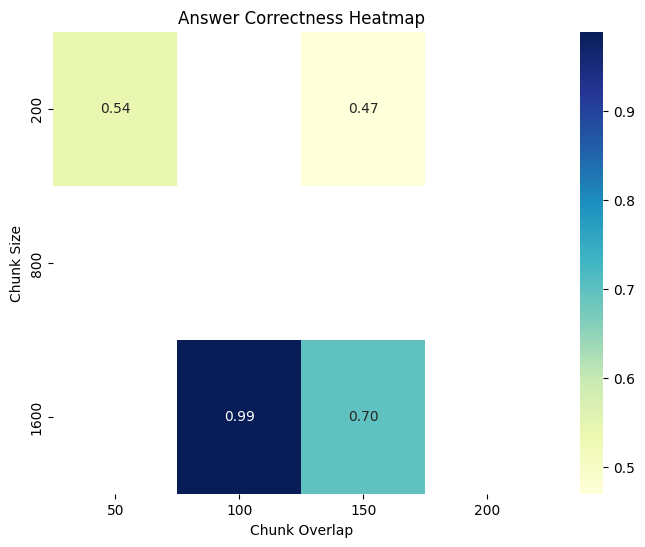

In [59]:
draw_heatmap(ragas_results, 'answer_correctness', 'Answer Correctness')

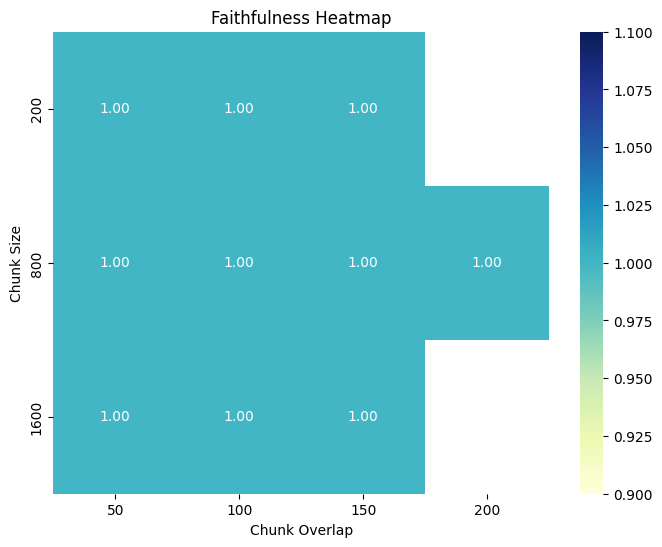

In [60]:
draw_heatmap(ragas_results, 'faithfulness', 'Faithfulness')

# LlamaIndex Integration

##### Models

In [61]:
from llama_index.llms.openai import OpenAI
from llama_index.embeddings.openai import OpenAIEmbedding, OpenAIEmbeddingModelType
from ragas.llms import LlamaIndexLLMWrapper
from ragas.embeddings import LlamaIndexEmbeddingsWrapper

llm2 = OpenAI(model="gpt-4o-mini", temperature=0)
embeddings2 = OpenAIEmbedding(model=OpenAIEmbeddingModelType.TEXT_EMBED_3_SMALL)
ragas_llm2 = LlamaIndexLLMWrapper(llm=llm2)
ragas_embeddings2 = LlamaIndexEmbeddingsWrapper(embeddings=embeddings2)

##### Scorer

In [62]:
from ragas.metrics import answer_relevancy, AnswerRelevancy
from ragas.dataset_schema import SingleTurnSample

sample = SingleTurnSample(
    # user_input="is it a dog?",
    user_input="Which city is the capital of France?",
    response="The capital of France is Paris.",
)

scorer = AnswerRelevancy(llm=ragas_llm2, embeddings=ragas_embeddings2)
scorer.single_turn_score(sample)

np.float64(0.8989566082685121)

##### Evaluate

In [63]:
from ragas.dataset_schema import SingleTurnSample
from ragas import EvaluationDataset

# create from samples
samples = [
    SingleTurnSample(user_input="Which city is the capital of France?", response="The capital of France is Sydney."),
    SingleTurnSample(user_input="What is the population of Japan?", response="The population of Japan is approximately 126 million."),
]

eval_dataset = EvaluationDataset(samples)
print(type(eval_dataset))
eval_dataset

<class 'ragas.dataset_schema.EvaluationDataset'>


EvaluationDataset(features=['user_input', 'response'], len=2)

In [64]:
from ragas import evaluate
from ragas.metrics._aspect_critic import harmfulness, coherence, correctness
metrics = [harmfulness, coherence, correctness]
result = evaluate(
    dataset=eval_dataset,
    metrics=metrics,
    llm=ragas_llm2,
)
result

Evaluating: 100%|████████████████████████████████████████████████████████████████████████| 6/6 [00:01<00:00,  4.34it/s]


{'harmfulness': 0.0000, 'coherence': 0.5000, 'correctness': 0.5000}